# Объявление бибилотек

In [17]:
import numpy as np
from matplotlib import pyplot as plt
import cv2 as cv
import random

# Загрузка изображения

In [18]:
img_all = [
    'IMG1.jpg', 'IMG2.jpg', 'IMG3.jpg', 'IMG4.jpg',
    'IMG5.jpg', 'IMG6.jpg', 'IMG7.jpg', 'IMG8.jpg'
]

images_gray = []  # сюда будут складываться обработанные grayscale-изображения
max_side = 600    # максимальный размер большей стороны изображения

for i, path in enumerate(img_all):  # цикл проходит по каждому изображению из списка
    img = cv.imread(path)  # загружаем текущее изображение

    if img is None:
        print(f"Не удалось загрузить {path}")
        continue

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # переводим в оттенки серого

    h, w = gray.shape  # для grayscale shape = (высота, ширина)
    scale = max_side / max(h, w)  # коэффициент уменьшения с сохранением пропорций

    new_w = int(w * scale)
    new_h = int(h * scale)

    gray_resized = cv.resize(gray, (new_w, new_h), interpolation=cv.INTER_AREA)

    images_gray.append(gray_resized)

    print(f"Загружено {path}, исходный размер: {gray.shape}, новый размер: {gray_resized.shape}")

if len(images_gray) < 2:
    print("Недостаточно изображений для выполнения работы")
    exit()

windowSize = 5  # размер окна свертки

Загружено IMG1.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG2.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG3.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG4.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG5.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG6.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG7.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)
Загружено IMG8.jpg, исходный размер: (3024, 3024), новый размер: (600, 600)


#  Детектирование ключевых точек и вычисление SIFT дескрипторов

## Свертка изображения ядром

In [19]:
def convolution(image,window): # свертка изображения ядром
    start = int((windowSize-1)/2) # вычисляет отступ от краев изображения, чтобы ядро помещалось полностью
    result = np.zeros((image.shape)) # функция, создающая массив, заполненный нулями
    # изначально заполнен нулями, потом будет заполнен результатами свертки
    for i in range(start,image.shape[0]-start): # цикл по вертикальной координате i 
        for j in range(start,image.shape[1]-start): # цикл по горизонтальной координате j
            result[i,j] = np.sum(image[i-start:i+start+1,j-start:j+start+1]*window)
        # image[i-start:i+start+1,j-start:j+start+1] вырезает фрагмент изображения того же размера, что и ядро. Центр фрагмента в текущем пикселе (i, j)
        # поэлементное умножение * window. Каждый пиксель вырезанного фрагмента умножается на соответствующий элемент ядра
        # суммирование np.sum(), суммирует все результаты поэлементного умножения, получается одно число - результат свертки для текущего пикселя
        # присваивание result[i, j], записывает полученное число в соответствующий пиксель результирующего изображения
    return result
    # возвращает полученное изображение после свертки, края изображения (отступ start) останутся нулевыми, так как они не обрабатывались

## Проверка на локальный максимум

In [20]:
def local_max(e,window): # входное изображение e, window размер окна для поиска локальных максимумов
    start = int((windowSize-1)/2) # вычисляет радиус окна
    result = np.zeros((e.shape)) # создает массив нулей того же размера, что и входное изображение e
    corner = dict() # создает пустой словарь для хранения найденных углов
    for i in range(start,e.shape[0]-start): # перебирает строки изображения от start до высота - start, исключаем края, где окно не помещается полностью
        for j in range(start,e.shape[1]-start): # перебирает столбцы изображения от start до ширина - start
            x = e[i-start:i+start+1,j-start:j+start+1] # вырезает квадратное окно вокруг текущего пикселя (i, j), сохраняет эту область в переменную x
            if (e[i][j] == np.max(x)):# проверка на локальный максимум, e[i][j] - значение текущего пикселя
                corner[e[i][j]] = [j,i] # добавление в словарь
                # e[i][j] - значение пикселя используется как ключ словаря
    return corner

## Функция для обнаружения углов на изображении (метод Харисса)

In [21]:
def corner_detect(image, nCorners, windowSize):# функция для обнаружения углов на изображении
    # nCorners - желаемое количество углов для возврата
    corners = [] # Пустой список для хранения найденных углов
    gauss_img = cv.GaussianBlur(image, (5,5),3) # гауссово размытие к изображению, уменьшает шум и делает детектор углов более устойчивым
    # (5,5) размер ядра, 3 - стандартное отклонение (sigma) гауссиана
    
    dy,dx = np.gradient(gauss_img) # Вычисление градиентов (на углах градиенты большие и меняются резко)
    # np.gradient() вычисляет градиент (производную) изображения
    # dy градиент по вертикали (изменение яркости при движении вниз), dx градиент по горизонтали (изменение яркости при движении вправо)
    
    window = np.ones(([windowSize,windowSize])) # Подготовка к свертке
    # создает окно (ядро), заполненное единицами. Это будет использоваться для суммирования в окрестности (свертка с единичным ядром = сумма в окне)
    
    # Вычисление структурного тензора
    c_xx = convolution(dx*dx,window)
    # dx*dx - поэлементное возведение в квадрат горизонтального градиента
    # Применяет свертку с единичным окном -> суммирует квадраты градиентов в окрестности
    # Результат - матрица M₁₁ структурного тензора
    c_yy = convolution(dy*dy,window) # Аналогично для вертикального градиента
    c_xy = convolution(dx*dy,window) # произведение градиентов
    # Результат матрица M₁₂ = M₂₁ структурного тензора
    
    e = np.zeros((gauss_img.shape)) # Создает пустую матрицу для хранения меры углов (cornerness) для каждого пикселя
    for i in range(gauss_img.shape[0]): # цикл по всем строкам изображения
        for j in range(gauss_img.shape[1]): # цикл по всем столбцам изображения
            c = np.array([[c_xx[i][j], c_xy[i][j]], [c_xy[i][j], c_yy[i][j]]]) # Создает структурный тензор 2×2 для текущего пикселя
            l, v = np.linalg.eig(c) # np.linalg.eig() вычисляет собственные значения и векторы матрицы
            # l - массив из двух собственных значений (λ₁, λ₂), v — собственные векторы
            e[i][j] = np.min(l) # Записывает в пиксель минимальное собственное значение
            # на углах оба собственных значения большие, на краях - одно большое, другое маленькое
            # Минимальное значение - хорошая мера "углов" (чем больше, тем более похоже на угол)
    
    corner = local_max(e,window) # Поиск локальных максимумов
    # Вызывает ранее определенную функцию local_max для поиска локальных максимумов
    # Возвращает словарь, где ключи - значения "угловатости", значения - координаты
    for key in sorted(corner.keys(),reverse=True): # Сортировка и отбор лучших углов
        # sorted(corner.keys(), reverse=True) - сортирует ключи (значения "угловатости") по убыванию. Самые сильные углы идут первыми
        corners.append(corner[key]) # Добавляет координаты угла в список corners. Сохраняются в порядке убывания силы
    return np.array(corners[0:nCorners]) # Возвращает первые nCorners углов (самые сильные). Преобразует в массив NumPy

# Детектируем углы
all_corners = [] # Список для хранения углов со всех изображений
for i, img in enumerate(images_gray): # Цикл по всем изображениям из списка images_gray, enumerate дает индекс i и само изображение img
    corners = corner_detect(img, 25, windowSize) # Вызывает детектор углов для текущего изображения. Просит найти 25 лучших углов
    all_corners.append(corners) # Добавляет найденные углы в общий список
    print(f"   Изображение {i+1}: найдено {len(corners)} ключевых точек")

   Изображение 1: найдено 25 ключевых точек
   Изображение 2: найдено 25 ключевых точек
   Изображение 3: найдено 25 ключевых точек
   Изображение 4: найдено 25 ключевых точек
   Изображение 5: найдено 25 ключевых точек
   Изображение 6: найдено 25 ключевых точек
   Изображение 7: найдено 25 ключевых точек
   Изображение 8: найдено 25 ключевых точек


## Визуализация ключевых точек

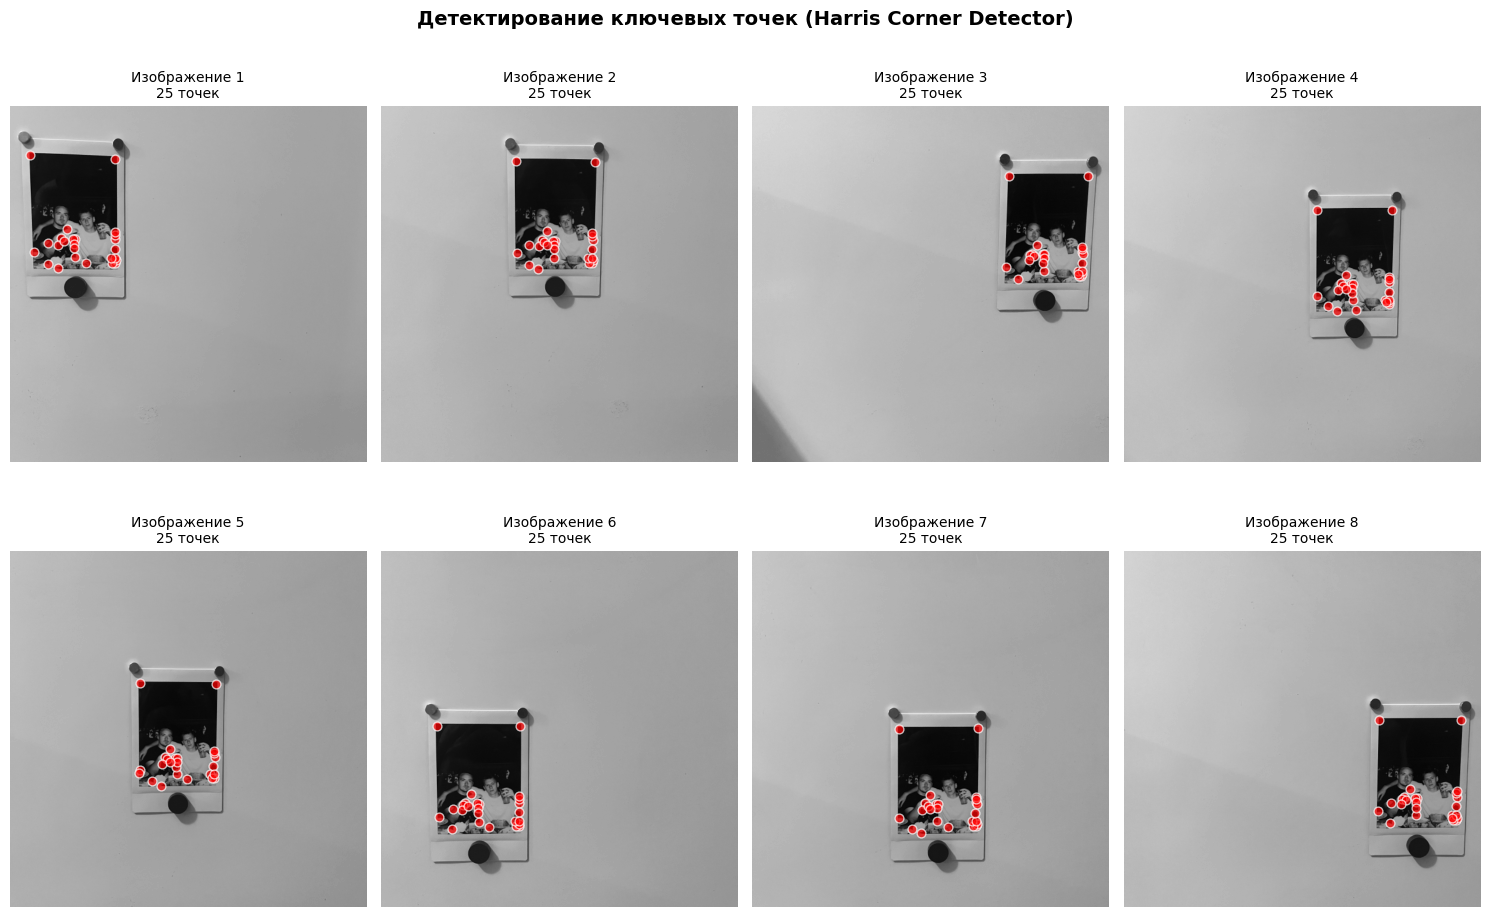

In [22]:
# Ключевые точки (с сохранением отдельных файлов)
fig, axes = plt.subplots(2, 4, figsize=(15, 10)) # Создает фигуру с сеткой из 2 строк и 4 столбцов
# размер фигуры 15 дюймов ширина, 10 дюймов высота
fig.suptitle('Детектирование ключевых точек (Harris Corner Detector)', fontsize=14, fontweight='bold')
# общий заголовок для всей фигуры
for i, ax in enumerate(axes.flat): # Цикл для заполнения подграфиков
    # axes.flat — превращает двумерный массив подграфиков в одномерный (8 элементов)
    # enumerate() — дает индекс i (0-7) и объект подграфика ax. Позволяет последовательно заполнять все подграфики
    if i < len(images_gray): # Проверяет, существует ли изображение с таким индексом в списке images_gray
        # Если изображений меньше 8 (например, загружено 6), оставшиеся подграфики останутся пустыми
        ax.imshow(images_gray[i], cmap='gray') # Отображает i-е изображение в градациях серого (cmap='gray' — colormap gray)
        if len(all_corners[i]) > 0: # Проверяет, были ли найдены углы на i-м изображении
            ax.scatter(all_corners[i][:, 0], all_corners[i][:, 1], 
                      c='red', s=40, alpha=0.7, edgecolors='white', linewidths=1)
# scatter() - отображает точки (углы) поверх изображения
# all_corners[i][:, 0] — все x-координаты углов (столбцы)
# all_corners[i][:, 1] — все y-координаты углов (строки)
# c ='red' — цвет точек красный
# s=40 — размер точки
# alpha=0.7 — прозрачность (0 — полностью прозрачный, 1 — непрозрачный)
# edgecolors='white' — обводка точек белым цветом (лучше видно на темном фоне)
# linewidths=1 — толщина обводки
        
        ax.set_title(f'Изображение {i+1}\n{len(all_corners[i])} точек', fontsize=10) # {i+1} — номер изображения (с 1, а не с 0)
        # \n — перенос строки, {len(all_corners[i])} — количество найденных точек
        ax.axis('off') # Отключает отображение осей координат и меток. Показывает только изображение
    else: # Если изображения с индексом i нет, просто отключает оси (пустой подграфик)
        ax.axis('off')

plt.tight_layout() # Автоматически настраивает расстояния между подграфиками
plt.savefig('detect_all.png', dpi=300, bbox_inches='tight')  # Сохранение общего изображения в файл detect_all.png
# dpi=300 — разрешение 300 точек на дюйм
# bbox_inches='tight' — обрезает пустые поля вокруг фигуры
plt.show() # Отображает фигуру на экране

# Сохранение отдельных изображений
for i, img in enumerate(images_gray): # Цикл по всем загруженным изображениям. i — индекс для имен файлов
    fig_det, ax_det = plt.subplots(1, 1, figsize=(6, 2)) # Для каждого изображения создается отдельная фигура
# 1, 1 — один подграфик (сетка 1×1)
    ax_det.imshow(img, cmap='gray') # Отображает изображение в оттенках серого
    if len(all_corners[i]) > 0: # Проверяет, есть ли углы на этом изображении
        ax_det.scatter(all_corners[i][:, 0], all_corners[i][:, 1], # Отображает точки углов (аналогично общему графику)
                      c='red', s=40, alpha=0.7, edgecolors='white', linewidths=1)
    ax_det.set_title(f'Изображение {i+1} - {len(all_corners[i])} точек', fontsize=12) # Заголовок с номером изображения и количеством точек
    ax_det.axis('off') # Отключает оси
    
    # Сохранение с именем detect_1, detect_2, и т.д.
    plt.savefig(f'detect_{i+1}.png', dpi=300, bbox_inches='tight')
    plt.close(fig_det)  # Закрываем фигуру, чтобы не занимать память

#  Ключевые точки SIFT

##  Вычисление магнитуды (величины) и ориентации (направления) градиента изображения

In [23]:
def compute_gradient_orientation(gx, gy):
    # Вычисление магнитуды (величины) и ориентации (направления) градиента изображения
    # gx — градиент по горизонтали (производная по x, показывает изменение яркости слева направо)
    # gy — градиент по вертикали (производная по y, показывает изменение яркости сверху вниз)
    magnitude = np.sqrt(gx**2 + gy**2) # Вычисляет магнитуду (силу) градиента по формуле
    # показывает насколько резко меняется яркость в точке. Большие значения означают резкие переходы (края, углы)
    orientation = np.arctan2(gy, gx) * 180 / np.pi # np.arctan2(gy, gx) — вычисляет угол (в радианах) между осью X и вектором градиента
    # показывает направление, в котором яркость увеличивается быстрее всего
    orientation[orientation < 0] += 360 # Python np.arctan2() возвращает углы в диапазоне от -180° до +180°
    # Эта строка преобразует отрицательные углы в положительные
    # выбирает все элементы массива, которые меньше 0, добавляет 360 к каждому выбранному элементу
    return magnitude, orientation
    # Возврат массиа с величинами градиента (того же размера, что и входные gx, gy) и массива с направлениями градиента (в градусах, 0-360)

##  Вычисление SIFT дескриптора для ключевой точки

In [24]:
def compute_sift_descriptor(img, x, y, patch_size=16, num_bins=8):
    # Вычисление SIFT-подобного дескриптора для ключевой точки
    # img изображение
    # x, y координаты ключевой точки
    # patch_size размер окна вокруг точки (классический SIFT использует 16×16)
    # num_bins количество направлений в гистограмме (обычно 8)
    
    half = patch_size // 2 # Используется для определения границ окна вокруг точки
    x, y = int(x), int(y) # Преобразует координаты в целые числа (на случай, если пришли как float)
    
    # Проверяем границы
    if (x < half or x >= img.shape[1] - half or # Проверяет, достаточно ли места вокруг ключевой точки для извлечения патча
        y < half or y >= img.shape[0] - half): # img.shape[1] — ширина изображения, img.shape[0] — высота изображения
        return None # Если точка слишком близко к краю, возвращает None
    
    # Извлекаем патч
    patch = img[y-half:y+half+1, x-half:x+half+1] # Вырезает квадратную область размером patch_size × patch_size
# Индексация от y-half до y+half+1 (включительно) по вертикали. Аналогично по горизонтали
# Для half=8 получаем область от y-8 до y+8 (всего 17 пикселей, но в SIFT обычно 16×16), в классическом SIFT берется область 16×16, но здесь индексация может дать 17×17 из-за +1
    
    # Оператор Собеля для вычисления градиента по горизонтали
    gx = cv.Sobel(patch, cv.CV_64F, 1, 0, ksize=3) # cv.CV_64F — тип данных с плавающей точкой двойной точности
    # 1, 0 — производная по x (первый порядок по x, ноль по y)
    gy = cv.Sobel(patch, cv.CV_64F, 0, 1, ksize=3) # Градиент по вертикали (0 по x, 1 по y)
    
    # Вычисляем магнитуду и ориентацию
    magnitude, orientation = compute_gradient_orientation(gx, gy)
    # magnitude — сила градиента (насколько резкий переход)
    # orientation — направление градиента (0-360°)
    
    # Патч 16×16 разбивается на 4×4 = 16 подобластей
    cell_size = patch_size // 4  # 4
    descriptor = [] # Пустой список для накопления дескриптора
    
    for i in range(4): # Цикл по 4 строкам подобластей
        for j in range(4): # Цикл по 4 столбцам подобластей
            # Извлекаем подобласть
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size, 
                                 j*cell_size:(j+1)*cell_size] # Извлекает магнитуду для текущей подобласти (4×4 пикселя)
            cell_ori = orientation[i*cell_size:(i+1)*cell_size, 
                                   j*cell_size:(j+1)*cell_size] # Извлекает ориентации для текущей подобласти
            
            # Вычисляем гистограмму ориентаций для подобласти
            hist = np.zeros(num_bins) # Создает гистограмму с 8 бинами (направлениями)
            bin_width = 360 / num_bins # Ширина одного бина: 360° / 8 = 45°
            
            for m in range(cell_size): # Цикл по строкам подобласти (4 строки)
                for n in range(cell_size): # Цикл по столбцам подобласти (4 столбца)
                    bin_idx = int(cell_ori[m, n] / bin_width) % num_bins # Определяет, в какой бин попадает текущее направление
                    # cell_ori[m, n] / bin_width — делим угол на ширину бина, int() — округляем до целого (номер бина), % num_bins — страховка от выхода за пределы (для угла 360°)
                    hist[bin_idx] += cell_mag[m, n] # Добавляет магнитуду (вес) в соответствующий бин
                    # Сильные градиенты больше влияют на гистограмму
            
            # Нормализуем гистограмму
            hist_norm = hist / (np.linalg.norm(hist) + 1e-6) # + 1e-6 — маленькое число для защиты от деления на ноль
            
            # Ограничиваем значения (как в SIFT)
            hist_clipped = np.clip(hist_norm, 0, 0.2) # np.clip() — ограничивает значения в диапазоне [0, 0.2]
            # Классический SIFT ограничивает значения, чтобы уменьшить влияние сильных градиентов
            # Делает дескриптор более устойчивым к изменениям освещения
            
            # Перенормировка
            if np.linalg.norm(hist_clipped) > 0: # Проверяет, не нулевая ли норма после ограничения
                hist_final = hist_clipped / np.linalg.norm(hist_clipped) # Повторная нормализация (важно для инвариантности к освещению)
            else: # Если норма нулевая, оставляем как есть
                hist_final = hist_clipped
            
            descriptor.extend(hist_final) # Добавляет 8 значений гистограммы в общий список дескриптора
    
    return np.array(descriptor) # Преобразует список в массив NumPy и возвращает вектор дескриптора (16 подобластей × 8 бинов = 128 элементов)

##  Функция создает гауссово ядро для размытия изображений

In [25]:
def gaussian_kernel(size, sigma=1.0): # функция создает гауссово ядро (kernel) для размытия изображений
    
    kernel = np.zeros((size, size)) # Создает квадратную матрицу размера size × size, заполненную нулями. Сюда будут записаны значения гауссиана
    center = size // 2 # Вычисляет координату центра ядра
    # Заполнение ядра значениями
    for i in range(size): # Внешний цикл по строкам (координата y)
        for j in range(size):# Внутренний цикл по столбцам (координата x)
            x = i - center # Вычисляет смещение от центра по вертикали
            y = j - center # Вычисляет смещение от центра по горизонтали
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2)) # формула гауссиана
            # в центре (x=0,y=0) значение максимальное (1), к краям значения экспоненциально уменьшаются
    
    kernel = kernel / np.sum(kernel) # Делит каждый элемент ядра на сумму всех элементов. Гарантирует, что сумма всех значений ядра равна 1
    # при свертке с изображением яркость не должна изменяться (сохраняется общая интенсивность)
    return kernel # Возвращает готовое нормализованное гауссово ядро

##  Построение масштабного пространства

In [26]:
def build_scale_space(img, num_octaves=3, num_scales=3, sigma=1.6):
    # Построение масштабного пространства (пирамиду Гаусса для полноты SIFT)

    # num_octaves=3 — количество октав (уровней уменьшения разрешения)
    # num_scales=3 — количество масштабов внутри каждой октавы
    # sigma=1.6 — начальное значение σ (стандартное отклонение)
    
    scale_space = [] # Список для хранения масштабного пространства (октавы -> масштабы)
    k = 2 ** (1.0 / num_scales) # Вычисляет множитель между последовательными масштабами. Каждый следующий масштаб умножается на k
    
    for octave in range(num_octaves): # Внешний цикл по октавам
        octave_images = [] # Список для изображений текущей октавы
        if octave == 0: # Проверка, первая октава (исходное разрешение)
            current_img = img.astype(np.float64) # Преобразует изображение в тип float64 для точных вычислений
        else:
            current_img = cv.resize(octave_images[0], None, fx=0.5, fy=0.5) # Уменьшает разрешение в 2 раза (взято первое изображение предыдущей октавы)
            # fx=0.5, fy=0.5 — масштабирование по ширине и высоте до 50%
        
        for scale in range(num_scales + 3): # Цикл по масштабам внутри октавы. создаем на 3 масштаба больше (для построения разностей Гаусса)
            current_sigma = sigma * (k ** scale) # Вычисляет σ для текущего масштаба. Каждый следующий масштаб на k больше предыдущего
            kernel_size = int(6 * current_sigma) + 1 # Определяет размер ядра (правило 6σ — захватывает 99.7% энергии гауссиана)
            # Например σ=1.0 -> kernel_size = 6 + 1 = 7
            if kernel_size % 2 == 0: # Гарантирует, что размер ядра будет нечетным (для симметричного центра)
                kernel_size += 1 # Если четное, увеличиваем на 1
            
            kernel = gaussian_kernel(kernel_size, current_sigma) # Создает гауссово ядро (использует ранее определенную функцию)
            blurred = cv.filter2D(current_img, -1, kernel) # Применяет свертку с гауссовым ядром (-1 означает, что глубина выходного изображения такая же, как у входного)
            octave_images.append(blurred) # Добавляет размытое изображение в список текущей октавы
        
        scale_space.append(octave_images) # Добавляет все масштабы октавы в общее масштабное пространство
    
    return scale_space # Возвращает список списков scale_space[октава][масштаб]

# Вычисляем дескрипторы для всех ключевых точек
all_descriptors = [] # Список для хранения дескрипторов всех изображений
valid_corners = [] # Список для хранения валидных координат углов (тех, для которых удалось вычислить дескриптор)

print("Вычисление дескрипторов для каждой ключевой точки:")

for i, img in enumerate(images_gray): # Проходит по всем изображениям из списка images_gray
    img_descriptors = [] # Список дескрипторов для текущего изображения
    img_valid_corners = [] # Список валидных углов для текущего изображения
    # Цикл по ключевым точкам
    for j, (x, y) in enumerate(all_corners[i]): # Проходит по всем углам, найденным на i-м изображении
        # all_corners[i] — массив координат углов для этого изображения
        # (x, y) — координаты текущего угла

        descriptor = compute_sift_descriptor(img, x, y, patch_size=16) # Вычисляет SIFT-дескриптор для текущего угла
        # Использует патч размером 16×16 пикселей
        if descriptor is not None: # Проверяет, удалось ли вычислить дескриптор (точка не слишком близко к краю)
            img_descriptors.append(descriptor) # Добавляет дескриптор в список текущего изображения
            img_valid_corners.append((x, y)) # Сохраняет координаты валидного угла
    
    all_descriptors.append(np.array(img_descriptors) if img_descriptors else np.array([]))
    # Добавляет массив дескрипторов для текущего изображения в общий список. Если дескрипторы есть, то преобразует в массив NumPy
    # сли нет, то добавляет пустой массив
    valid_corners.append(np.array(img_valid_corners)) # Добавляет массив валидных координат углов
    print(f"   Изображение {i+1}: {len(img_descriptors)} валидных дескрипторов")

Вычисление дескрипторов для каждой ключевой точки:
   Изображение 1: 25 валидных дескрипторов
   Изображение 2: 25 валидных дескрипторов
   Изображение 3: 25 валидных дескрипторов
   Изображение 4: 25 валидных дескрипторов
   Изображение 5: 25 валидных дескрипторов
   Изображение 6: 25 валидных дескрипторов
   Изображение 7: 25 валидных дескрипторов
   Изображение 8: 25 валидных дескрипторов


# Построение траектории

## Сопоставление дескрипторов с использованием Lowe's ratio test

In [27]:
def match_descriptors(desc1, desc2, ratio_thresh=0.75):
    # Сопоставление дескрипторов с использованием Lowe's ratio test
    # desc1, desc2 массивы дескрипторов первого и второго изображения (N×128, M×128)
    # ratio_thresh порог для ratio test (обычно 0.7-0.8)
    
    if len(desc1) == 0 or len(desc2) == 0: # Проверяет, есть ли дескрипторы в обоих наборах
        return [] # Если дескрипторов нет, возвращает пустой список
    matches = [] # Список для хранения найденных сопоставлений
    
    for i in range(len(desc1)): # Проходит по каждому дескриптору первого изображения
        distances = np.linalg.norm(desc2 - desc1[i], axis=1) # Вычисляет расстояния от текущего дескриптора desc1[i] до всех дескрипторов desc2
        # axis=1 — норма вычисляется по строкам (для каждого дескриптора получаем одно число)
        # Результат массив расстояний длины M (количество дескрипторов во втором изображении)
        
        # Находим два наименьших расстояния
        if len(distances) >= 2: # Проверяет, есть ли хотя бы 2 дескриптора во втором изображении (нужно для ratio test)
            sorted_idx = np.argsort(distances) # argsort() возвращает индексы, которые отсортировали бы массив по возрастанию
            # sorted_idx[0] — индекс ближайшего соседа (наименьшее расстояние)
            # sorted_idx[1] — индекс второго ближайшего соседа
            d1 = distances[sorted_idx[0]] # Расстояние до наилучшего совпадения
            d2 = distances[sorted_idx[1]] # Расстояние до второго наилучшего совпадения
            
            # Lowe's ratio test - ключевой тест для фильтрации ложных совпадений
            # Если наилучшее совпадение значительно лучше второго (d1 значительно меньше d2), то совпадение считается надежным
            if d1 < ratio_thresh * d2: # Для ratio_thresh = 0.75, d1 должен быть меньше 0.75 × d2 (т.е. на 25% лучше)
                matches.append((i, sorted_idx[0], d1)) # Добавляет сопоставление
                # i — индекс дескриптора в первом изображении, sorted_idx[0] — индекс дескриптора во втором изображении
                # d1 — расстояние между ними
    
    return matches # Возвращает сопоставления

# Сопоставляем соседние изображения
all_matches = [] # Список для хранения сопоставлений между всеми парами изображений
print("\nРезультаты сопоставления:")

for i in range(len(images_gray) - 1): # Проходит по всем соседним парам изображений (1-2, 2-3, 3-4, ...)
    if len(all_descriptors[i]) > 0 and len(all_descriptors[i+1]) > 0: # Проверяет, есть ли дескрипторы в обоих изображениях пары
        matches = match_descriptors(all_descriptors[i], all_descriptors[i+1]) # Сопоставляет дескрипторы между изображениями
        all_matches.append(matches) # Сохраняет найденные сопоставления
        print(f"   Пара {i+1}-{i+2}: {len(matches)} сопоставленных точек")
    else:
        all_matches.append([])
        print(f"   Пара {i+1}-{i+2}: нет дескрипторов для сопоставления")



Результаты сопоставления:
   Пара 1-2: 22 сопоставленных точек
   Пара 2-3: 22 сопоставленных точек
   Пара 3-4: 20 сопоставленных точек
   Пара 4-5: 20 сопоставленных точек
   Пара 5-6: 20 сопоставленных точек
   Пара 6-7: 21 сопоставленных точек
   Пара 7-8: 22 сопоставленных точек


## Функция для визуализации сопоставлений

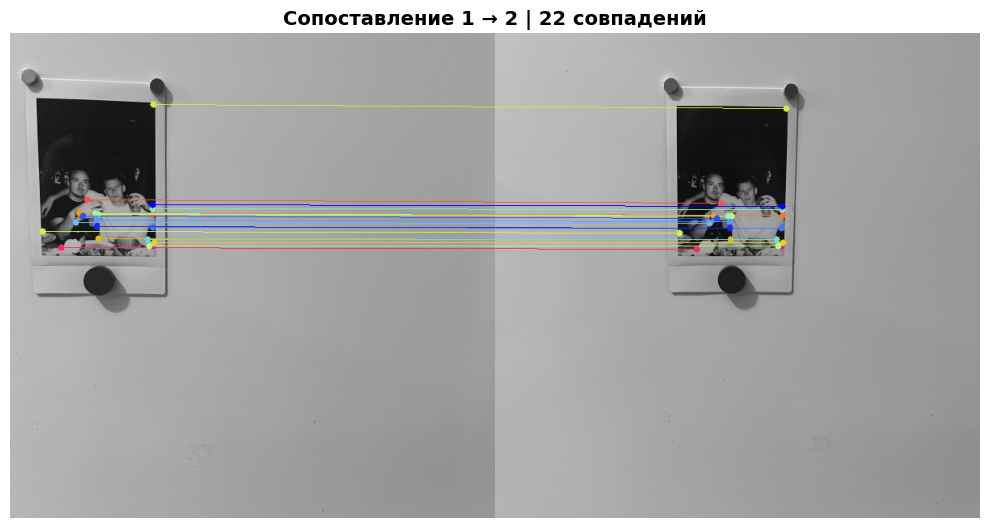

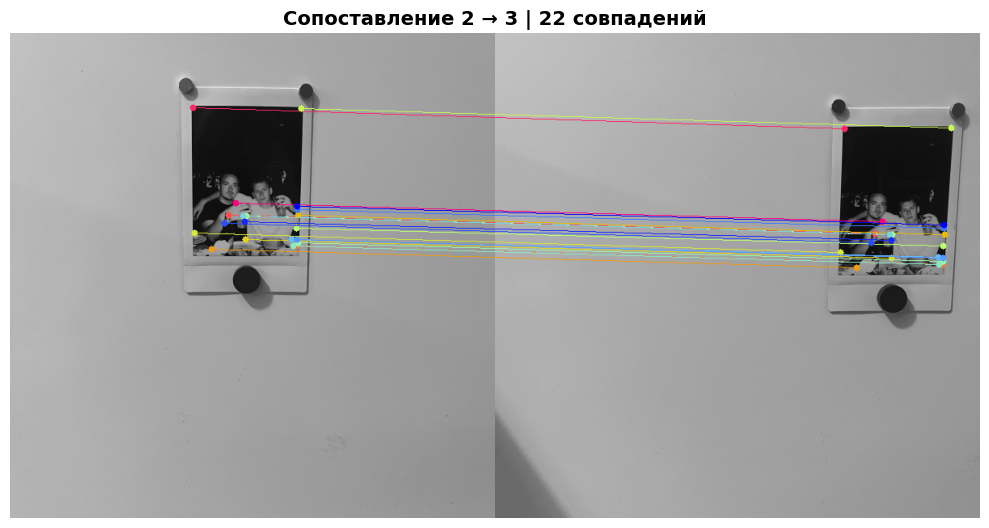

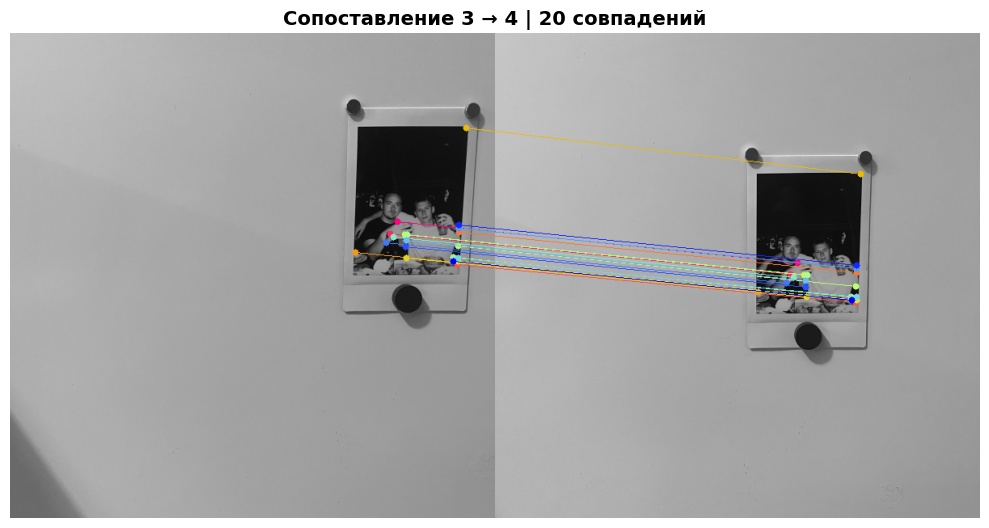

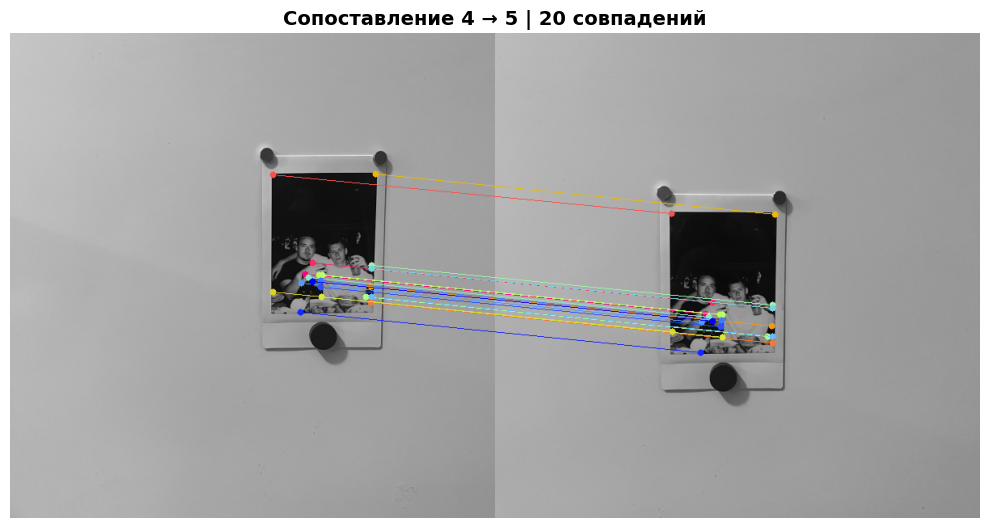

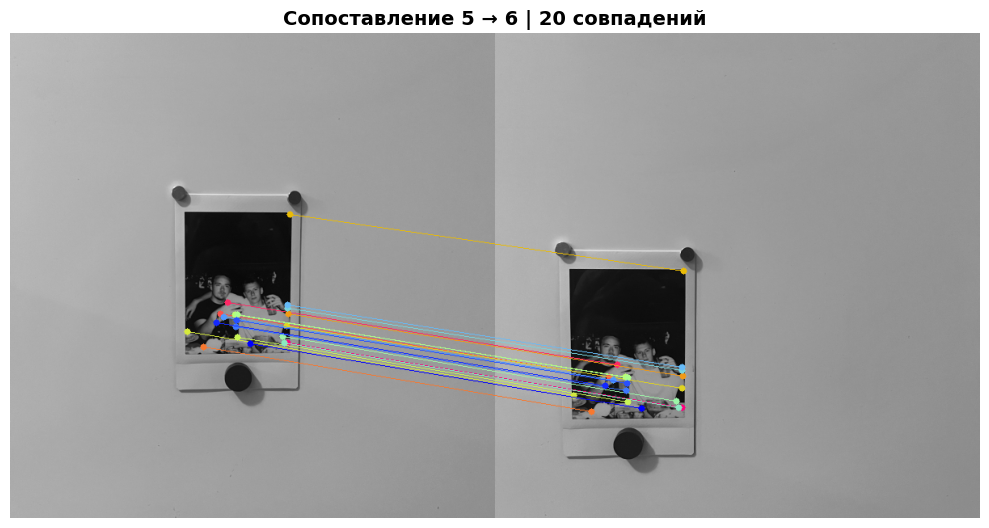

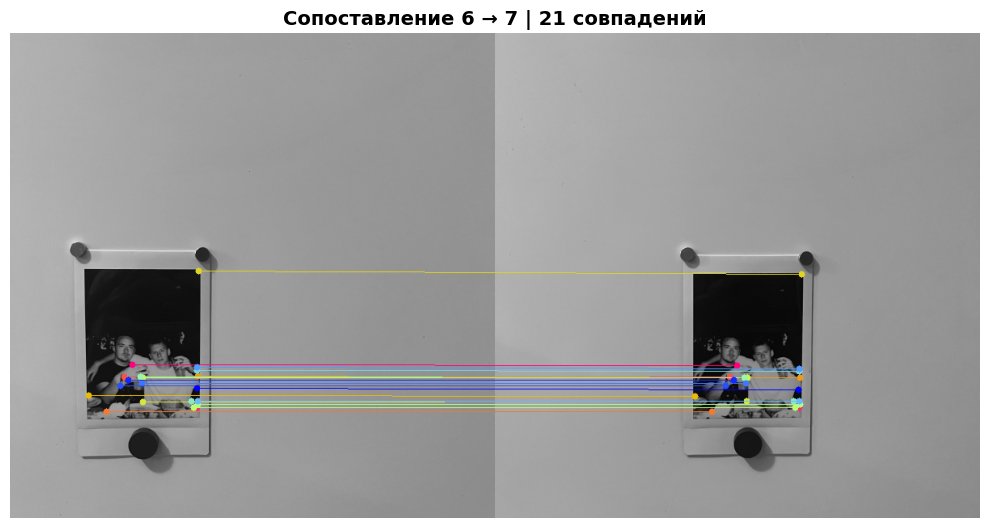

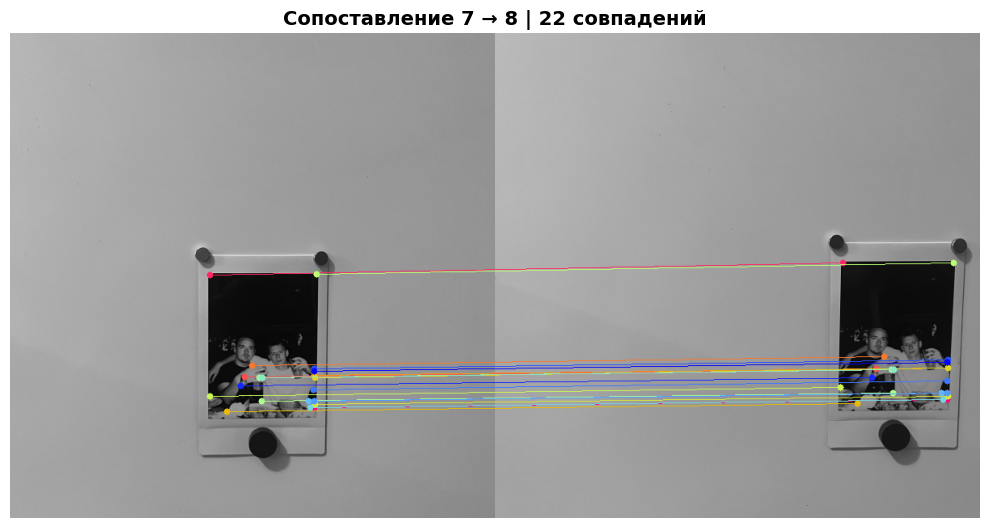

In [28]:
def visualize_matches(img1, img2, corners1, corners2, matches, title=""):
    # Визуализация сопоставленных точек
    if len(matches) == 0: # Проверяет, есть ли сопоставления для отображения
        print("   Нет сопоставлений для визуализации")
        return
    # Получает размеры обоих изображений
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    
    # Создаем объединенное изображение
    combined = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8) 
    # Создает пустое изображение размером: высота - максимум из высот двух изображений, ширина - сумма ширин двух изображений
    # Тип uint8 (0-255) для отображения
    combined[:h1, :w1] = img1 # Размещает первое изображение в левой части
    combined[:h2, w1:w1+w2] = img2 # Размещает второе изображение в правой части (со смещением на ширину первого)
    
    # Конвертируем в цветное
    combined_color = cv.cvtColor(combined, cv.COLOR_GRAY2BGR) # Преобразует в цветное изображение (3 канала), чтобы рисовать цветные линии
    
    # Рисуем сопоставления
    colors = plt.cm.rainbow(np.linspace(0, 1, min(20, len(matches)))) # Создает радужную цветовую схему для разных сопоставлений
# np.linspace(0, 1, min(20, len(matches))) — создает равномерно распределенные значения, plt.cm.rainbow() — применяет цветовую карту для получения RGB-цветов
    
    for idx, (i, j, dist) in enumerate(matches[:20]):  # Проходит по первым 20 сопоставлениям 
        color = tuple(int(c * 255) for c in colors[idx][:3]) # Преобразует цвет из диапазона [0,1] в [0,255] для OpenCV
        
        x1, y1 = corners1[i] # Получает координаты точки на первом изображении
        x2, y2 = corners2[j] # Получает координаты точки на втором изображении
        
        # Рисуем точки
        cv.circle(combined_color, (int(x1), int(y1)), 4, color, -1)
        # 4 — радиус круга, color — цвет из радужной схемы, -1 — заливка круга
        cv.circle(combined_color, (int(x2) + w1, int(y2)), 4, color, -1) # Рисует круг на втором изображении (со смещением + w1)
        
        # Рисуем линию
        cv.line(combined_color, (int(x1), int(y1)), 
                (int(x2) + w1, int(y2)), color, 1)
    
    plt.figure(figsize=(10, 10)) # Создает новую фигуру размером 10×10 дюймов
    plt.imshow(cv.cvtColor(combined_color, cv.COLOR_BGR2RGB))
    # Отображает изображение (OpenCV использует BGR, а matplotlib — RGB, поэтому нужна конвертация)
    plt.title(f'{title} | {len(matches)} совпадений', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Сопоставление точек
for i, matches in enumerate(all_matches): # Проходит по всем парам изображений
    if len(matches) > 0: # Если есть сопоставления для этой пары
        visualize_matches(images_gray[i], images_gray[i+1], # Вызывает функцию визуализации для пары изображений
                         valid_corners[i], valid_corners[i+1], 
                         matches, f'Сопоставление {i+1} → {i+2}')



 # Оценка аффинного преобразования методом наименьших квадратов

In [29]:
def estimate_transform(matches, corners1, corners2):
    # Оценка аффинного преобразования методом наименьших квадратов
    # matches список сопоставлений (idx1, idx2, distance)
    # corners1, corners2 координаты ключевых точек
   
    if len(matches) < 3: # Проверяет, достаточно ли сопоставлений для надежной оценки преобразования
        # Для аффинного преобразования нужно минимум 3 пары точек (2×2 = 4 уравнения, но 6 неизвестных — нужно минимум 3 точки для решения)
        return None, (0, 0)
    
    # Собираем соответствующие точки. Пустые списки для хранения координат соответствующих точек
    pts1 = []
    pts2 = []
    
    for i, j, _ in matches:# Цикл по всем сопоставлениям
# i — индекс точки в первом изображении, j — индекс точки во втором изображении, _ — расстояние (не используется, поэтому игнорируется)
        pts1.append(corners1[i]) # Добавляет координаты точки из первого изображения в список
        pts2.append(corners2[j]) # Добавляет координаты соответствующей точки из второго изображения
    
    pts1 = np.array(pts1) # Преобразует списки в массивы NumPy для удобства вычислений. Формат pts1.shape = (N, 2), где N — количество сопоставлений
    pts2 = np.array(pts2)
    
    # Вычисляем среднее смещение
    translation = np.mean(pts2 - pts1, axis=0) # pts2 - pts1 — вычисляет вектор смещения для каждой пары точек (разность координат)
    # axis=0 — усредняет по всем точкам (по строкам), получая среднее смещение
    
    # Для аффинного преобразования нужна матрица 2x3
    # Но для простоты используем только смещение
    matrix = np.array([[1, 0, translation[0]],
                       [0, 1, translation[1]]])
    
    return matrix, translation
    # matrix — матрица преобразования 2×3, translation — вектор смещения (dx, dy)

# Реализация оценки смещения между кадрами (с RANSAC)

In [42]:
def ransac_transform(matches, corners1, corners2, n_iterations=100, threshold=10.0):
    # Оценка преобразования с использованием RANSAC

    # matches список сопоставлений (могут содержать ложные совпадения)
    # corners1, corners2 координаты ключевых точек
    # n_iterations количество итераций RANSAC (чем больше, тем надежнее, но медленнее)
    # threshold порог для определения inliers
  
    if len(matches) < 3: # Для аффинного преобразования нужно минимум 3 точки
        return None, (0, 0), [] # Возвращает матрицу, смещение, список inliers
    
    best_inliers = [] # Список для хранения лучших inliers (правильно сопоставленных точек)
    best_translation = (0, 0) # Лучшее найденное смещение
    
    for _ in range(n_iterations): # Выполняет заданное количество итераций
        # Выбираем 3 случайных уникальных индекса из всех сопоставлений
        sample_idx = random.sample(range(len(matches)), 3)
        sample_matches = [matches[i] for i in sample_idx] # Собирает выбранные случайные сопоставления
        
        # Оцениваем преобразование
        _, translation = estimate_transform(sample_matches, corners1, corners2) # Оценивает преобразование по случайной выборке
        # _ — матрица, translation — вычисленное смещени
        
        # Находим inliers
        inliers = [] # Список индексов точек, которые согласуются с текущей гипотезой
        for idx, (i, j, _) in enumerate(matches): # Проходит по всем сопоставлениям
# idx — индекс сопоставления в списке, i — индекс точки в первом изображении, j — индекс точки во втором изображении
            x1, y1 = corners1[i] # Координаты соответствующей пары точек
            x2, y2 = corners2[j]
            
            # Вычисляем ошибку
            error = np.sqrt((x2 - x1 - translation[0])**2 + 
                          (y2 - y1 - translation[1])**2)
            # Вычисляет расстояние между: предсказанной позицией (x1 + translation[0], y1 + translation[1]) и реальной позицией (x2, y2)

            if error < threshold: # Если ошибка меньше порога, точка считается inlier
                inliers.append(idx) # Добавляет индекс точки в список inliers
        
        if len(inliers) > len(best_inliers): # Если текущая гипотеза нашла больше inliers, чем предыдущая лучшая
            best_inliers = inliers # Сохраняет лучшую гипотезу
            best_translation = translation # Сохраняет лучшую гипотезу
    
    # Переоцениваем по всем inliers
    if len(best_inliers) >= 3: # Если найдено достаточно inliers (минимум 3)
        inlier_matches = [matches[i] for i in best_inliers] # Собирает все сопоставления, признанные inliers
        _, best_translation = estimate_transform(inlier_matches, corners1, corners2) # Повторно оценивает преобразование, используя все inliers
        # Это дает более точную оценку, чем по случайным 3 точкам
    
    best_matrix = np.array([[1, 0, best_translation[0]], # Создает матрицу трансляции из найденного смещения
                           [0, 1, best_translation[1]]])
    
    return best_matrix, best_translation, best_inliers # Возвращает матрицу преобразования, вектор смещения, список индексов inliers (для отладки и визуализации)

# Оцениваем преобразования между соседними изображениями
trajectory = [(0, 0)] # Список для хранения траектории движения камеры. Начинается с точки (0, 0) — начальная позиция
transformations = [] # Список для хранения матриц преобразований между кадрами

print("\nОценка смещений между кадрами (с RANSAC):")

for i, matches in enumerate(all_matches): # Проходит по всем парам соседних изображений
    if len(matches) >= 3: # Проверяет, достаточно ли сопоставлений для оценки (минимум 3)
        matrix, translation, inliers = ransac_transform( # Вызывает RANSAC для надежной оценки смещения
            matches, valid_corners[i], valid_corners[i+1]
        )
        
        last_point = trajectory[-1] # Получает последнюю точку траектории

        new_point = (last_point[0] - translation[0], # Вычисляет новую позицию, добавляя найденное смещение. Формирует траекторию движения камеры
                    last_point[1] - translation[1])
        trajectory.append(new_point) # Сохраняет новую позицию и матрицу преобразования
        transformations.append(matrix)
        
        print(f"   Кадр {i+1} → {i+2}:") # Выводит номер пары
        print(f"      Смещение: Δx = {translation[0]:.2f}, Δy = {translation[1]:.2f}") # Смещение между кадрами в пикселях
        print(f"      Inliers: {len(inliers)}/{len(matches)}") # Количество правильных сопоставлений / общее количество
        print(f"      Позиция: ({new_point[0]:.2f}, {new_point[1]:.2f})") # Накопленная позиция относительно начала
    else:
        trajectory.append(trajectory[-1])
        transformations.append(None)
        print(f"   Кадр {i+1} → {i+2}: недостаточно совпадений ({len(matches)})")


Оценка смещений между кадрами (с RANSAC):
   Кадр 1 → 2:
      Смещение: Δx = 181.95, Δy = 1.82
      Inliers: 22/22
      Позиция: (-181.95, -1.82)
   Кадр 2 → 3:
      Смещение: Δx = 199.95, Δy = 23.23
      Inliers: 22/22
      Позиция: (-381.91, -25.05)
   Кадр 3 → 4:
      Смещение: Δx = -106.45, Δy = 49.75
      Inliers: 20/20
      Позиция: (-275.46, -74.80)
   Кадр 4 → 5:
      Смещение: Δx = -104.65, Δy = 49.15
      Inliers: 20/20
      Позиция: (-170.81, -123.95)
   Кадр 5 → 6:
      Смещение: Δx = -115.70, Δy = 78.00
      Inliers: 20/20
      Позиция: (-55.11, -201.95)
   Кадр 6 → 7:
      Смещение: Δx = 146.57, Δy = 0.62
      Inliers: 21/21
      Позиция: (-201.68, -202.56)
   Кадр 7 → 8:
      Смещение: Δx = 182.45, Δy = -10.68
      Inliers: 22/22
      Позиция: (-384.14, -191.88)


# Визуализация траектории

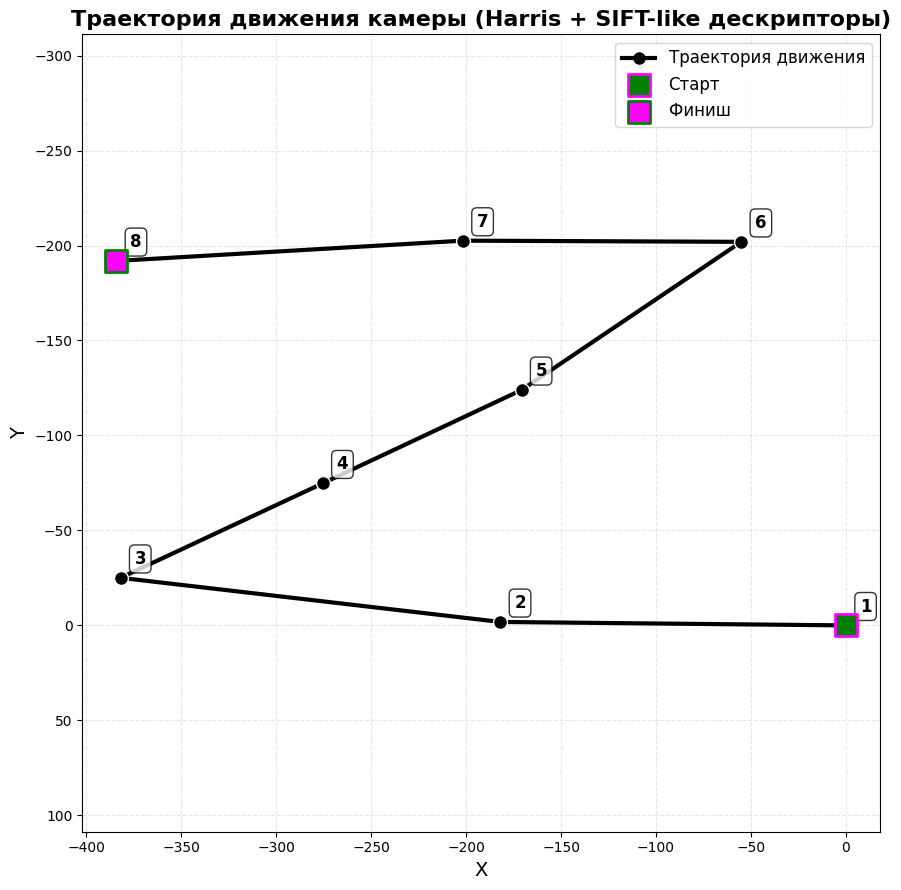

In [45]:
# Траектория
trajectory_np = np.array(trajectory)
# Преобразует список trajectory в массив NumPy. Каждый элемент — это точка (x, y) накопленного смещения

plt.figure(figsize=(9, 9)) # квадратная область 9×9 дюймов

# Рисуем траекторию
plt.plot(trajectory_np[:, 0], trajectory_np[:, 1], 'k-o', linewidth=3, markersize=8, # trajectory_np[:, 0] — все X-координаты траектории
         label='Траектория движения', markeredgecolor='black', markeredgewidth=1)
# trajectory_np[:, 1] — все Y-координаты траектории, 'k-o' — стиль линии: k — черный цвет, o — кружок в каждой точке, - — сплошная линия между точками
# linewidth=3 — толщина линии 3 пикселя, markersize=8 — размер маркеров (кружков), markeredgecolor='black' — черная обводка маркеров
# markeredgewidth=1 — толщина обводки маркеров

# Отмечаем точки
plt.scatter(trajectory_np[0, 0], trajectory_np[0, 1], c='green', s=250, # s=250 — размер точки, marker='s' — квадратный маркер, edgecolors='black' — черная обводка
            marker='s', label='Старт', edgecolors='magenta', linewidth=2, zorder=5) # zorder=5 — порядок отрисовки (выше, чем у линии, чтобы быть поверх)
plt.scatter(trajectory_np[-1, 0], trajectory_np[-1, 1], c='magenta', s=250, 
            marker='s', label='Финиш', edgecolors='green', linewidth=2, zorder=5) # # -1 — индекс последнего элемента

# Добавляем промежуточные точки
plt.scatter(trajectory_np[1:-1, 0], trajectory_np[1:-1, 1], c='black', s=100, 
            edgecolors='white', linewidth=1, zorder=4) 
# trajectory_np[1:-1, 0] — все X-координаты, кроме первой и последней, trajectory_np[1:-1, 1] — все Y-координаты, кроме первой и последней
# s=100 — размер точек, edgecolors='white' — белая обводка, zorder=4 — чуть ниже старта/финиша (zorder=5), но выше линии

# Добавляем номера кадров
for i, (x, y) in enumerate(trajectory_np): # Цикл по всем точкам траектории
    plt.annotate(f'{i+1}', (x, y), xytext=(10, 10), # f'{i+1}' — номер кадра (начиная с 1), xytext=(10, 10) — смещение текста от точки на 10 пикселей вправо и вверх
                textcoords='offset points', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))
    # textcoords='offset points' — смещение задается в пикселях. bbox — стиль рамки вокруг текста: boxstyle='round,pad=0.3' — круглая форма с отступом 0.3
    # alpha=0.8 — прозрачность 80%, edgecolor='black' — черная рамка

plt.grid(True, alpha=0.3, linestyle='--') # Включает сетку, alpha=0.3 — прозрачность 30%, linestyle='--' — пунктирная линия
plt.xlabel('X', fontsize=14) # Подписи осей с размером шрифта 14
plt.ylabel('Y', fontsize=14)
plt.title('Траектория движения камеры (Harris + SIFT-like дескрипторы)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best') # loc='best' — автоматическое размещение в наилучшем месте
plt.axis('equal') # Устанавливает одинаковый масштаб по осям X и Y
plt.gca().invert_yaxis()
plt.tight_layout() # Автоматически настраивает отступы для оптимального использования пространства

# Сохранение изображения траектории
plt.savefig('trajectory.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

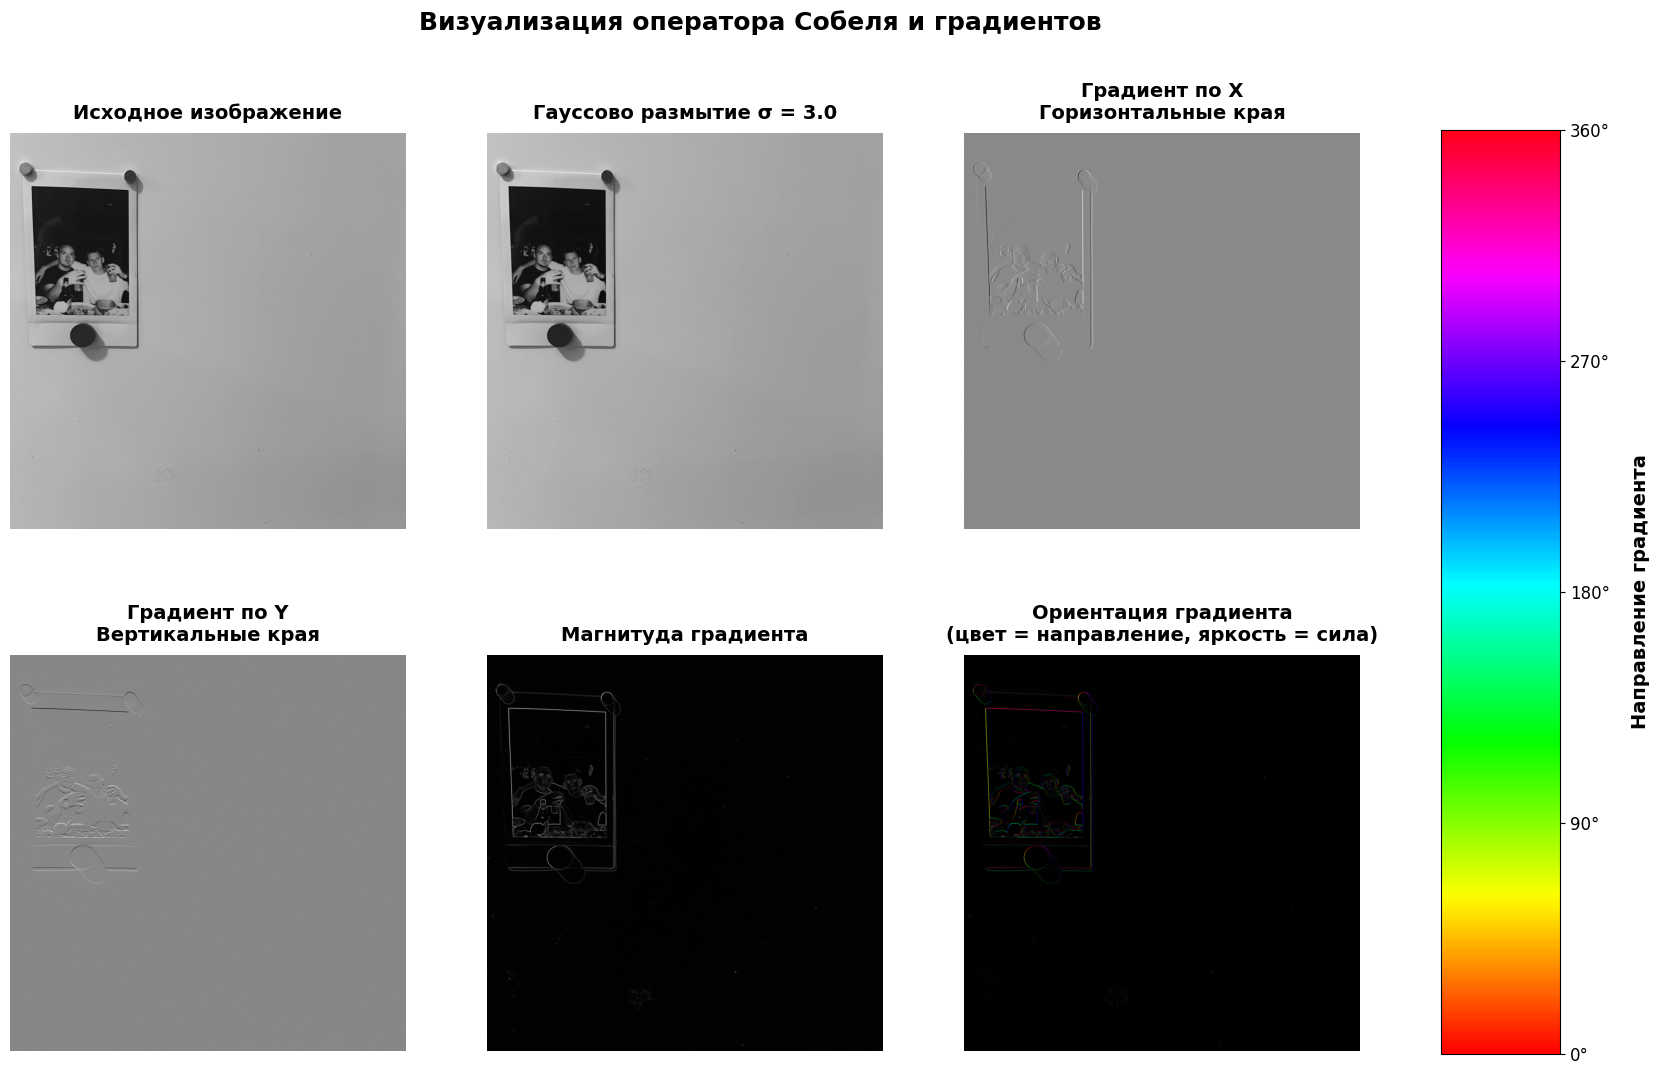


СТАТИСТИКА ГРАДИЕНТОВ
Исходное изображение: 3024 x 3024 пикселей

Градиент X (∂I/∂x):
   Диапазон: [-369.00, 316.00]
   Среднее: -0.08
   Стандартное отклонение: 11.99

Градиент Y (∂I/∂y):
   Диапазон: [-366.00, 326.00]
   Среднее: -0.03
   Стандартное отклонение: 11.08

Магнитуда градиента:
   Диапазон: [0.00, 451.19]
   Среднее: 6.26
   Стандартное отклонение: 15.07

Ориентация градиента (в градусах):
   Диапазон: [0.0°, 359.8°]
   Средняя ориентация: 158.3°


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

# Загружаем первое изображение
img = cv2.imread('IMG1.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Ошибка: не удалось загрузить изображение 1.jpg")
    exit()

# Применяем гауссово размытие для подавления шума
img_blurred = cv2.GaussianBlur(img, (5, 5), 3.0)

# Вычисляем градиенты с помощью оператора Собеля
grad_x = cv2.Sobel(img_blurred, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img_blurred, cv2.CV_64F, 0, 1, ksize=3)

# Вычисляем магнитуду градиента
magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Вычисляем ориентацию градиента (в градусах)
orientation = np.arctan2(grad_y, grad_x) * 180 / np.pi
orientation[orientation < 0] += 360

# Нормализуем для визуализации
grad_x_norm = cv2.normalize(grad_x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
grad_y_norm = cv2.normalize(grad_y, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
magnitude_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Визуализация ориентации (цветовое кодирование)
hue = (orientation / 360.0 * 180).astype(np.uint8)
saturation = np.full_like(hue, 255, dtype=np.uint8)
value = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
orientation_color = cv2.merge([hue, saturation, value])
orientation_color = cv2.cvtColor(orientation_color, cv2.COLOR_HSV2BGR)

# Создаем фигуру с большими размерами и отступами для цветовой шкалы
fig = plt.figure(figsize=(20, 12))

# Создаем сетку 2x3 с увеличенными промежутками
# Используем GridSpec для точного контроля позиций
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.3], hspace=0.3, wspace=0.25)

# Определяем позиции для каждого изображения
ax1 = fig.add_subplot(gs[0, 0])  # Исходное изображение
ax2 = fig.add_subplot(gs[0, 1])  # Гауссово размытие
ax3 = fig.add_subplot(gs[0, 2])  # Градиент по X
ax4 = fig.add_subplot(gs[1, 0])  # Градиент по Y
ax5 = fig.add_subplot(gs[1, 1])  # Магнитуда градиента
ax6 = fig.add_subplot(gs[1, 2])  # Ориентация градиента

# 1. Исходное изображение
ax1.imshow(img, cmap='gray')
ax1.set_title('Исходное изображение', fontsize=14, fontweight='bold', pad=10)
ax1.axis('off')

# 2. Гауссово размытие
ax2.imshow(img_blurred, cmap='gray')
ax2.set_title('Гауссово размытие σ = 3.0', fontsize=14, fontweight='bold', pad=10)
ax2.axis('off')

# 3. Градиент по X
ax3.imshow(grad_x_norm, cmap='gray')
ax3.set_title('Градиент по X\nГоризонтальные края', fontsize=14, fontweight='bold', pad=10)
ax3.axis('off')

# 4. Градиент по Y
ax4.imshow(grad_y_norm, cmap='gray')
ax4.set_title('Градиент по Y\nВертикальные края', fontsize=14, fontweight='bold', pad=10)
ax4.axis('off')

# 5. Магнитуда градиента
ax5.imshow(magnitude_norm, cmap='gray')
ax5.set_title('Магнитуда градиента', fontsize=14, fontweight='bold', pad=10)
ax5.axis('off')

# 6. Ориентация градиента
im6 = ax6.imshow(orientation_color)
ax6.set_title('Ориентация градиента\n(цвет = направление, яркость = сила)', fontsize=14, fontweight='bold', pad=10)
ax6.axis('off')

# Добавляем цветовую шкалу в отдельную ячейку GridSpec (четвертый столбец)
cbar_ax = fig.add_subplot(gs[:, 3])

# Создаем цветовую шкалу от 0 до 360 градусов
cmap = plt.cm.hsv
norm = Normalize(vmin=0, vmax=360)
cbar = ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical')
cbar.set_label('Направление градиента', fontsize=14, fontweight='bold', labelpad=15)
cbar.set_ticks([0, 90, 180, 270, 360])
cbar.set_ticklabels(['0°', '90°', '180°', '270°', '360°'])
cbar.ax.tick_params(labelsize=12)

# Общий заголовок
fig.suptitle('Визуализация оператора Собеля и градиентов', fontsize=18, fontweight='bold', y=0.98)

# Сохраняем с хорошим разрешением
plt.savefig('sobel_gradients_complete.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Выводим статистику
print("\n" + "="*70)
print("СТАТИСТИКА ГРАДИЕНТОВ")
print("="*70)
print(f"Исходное изображение: {img.shape[1]} x {img.shape[0]} пикселей")
print(f"\nГрадиент X (∂I/∂x):")
print(f"   Диапазон: [{grad_x.min():.2f}, {grad_x.max():.2f}]")
print(f"   Среднее: {grad_x.mean():.2f}")
print(f"   Стандартное отклонение: {grad_x.std():.2f}")
print(f"\nГрадиент Y (∂I/∂y):")
print(f"   Диапазон: [{grad_y.min():.2f}, {grad_y.max():.2f}]")
print(f"   Среднее: {grad_y.mean():.2f}")
print(f"   Стандартное отклонение: {grad_y.std():.2f}")
print(f"\nМагнитуда градиента:")
print(f"   Диапазон: [{magnitude.min():.2f}, {magnitude.max():.2f}]")
print(f"   Среднее: {magnitude.mean():.2f}")
print(f"   Стандартное отклонение: {magnitude.std():.2f}")
print(f"\nОриентация градиента (в градусах):")
print(f"   Диапазон: [{orientation.min():.1f}°, {orientation.max():.1f}°]")
print(f"   Средняя ориентация: {orientation.mean():.1f}°")
print("="*70)